# HCR Cell×Gene Viewer (Raw Counts, Leiden-Named Clusters)

Loads a mouse's pairwise unmixed cell×gene table and plots it ordered by
the Leiden-named cluster assignments from the matching pipeline.

Uses raw spot counts (not z-scored) for interpretability.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from aind_hcr_data_loader import get_hcr_dataset_pairwise
import aind_hcr_qc.viz as viz


# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [2]:
# ============ SETTINGS ============
MOUSE_ID = "788406"
DATA_DIR = Path("/root/capsule/data")
RESULTS_DIR = Path("/root/capsule/results/hcr_tasic_matching/stage5")
ASSIGNMENTS_FILE = RESULTS_DIR / "hcr_assignments_leiden_named.csv"

# Use log1p transform for visual comparison with Tasic (log CP10K scale)
LOG_TRANSFORM = False

# Clip range for the heatmap
CLIP_RANGE = (0, 8) if LOG_TRANSFORM else (0, 200)

# Minimum Pearson correlation to best centroid to keep a cell
MIN_CONFIDENCE = 0.5

COREG_CELLS_ONLY = True

In [44]:
coreg_cells.dtypes

czstack_id    int64
hcr_id        int64
dtype: object

In [3]:
# Load pairwise unmixed cell x gene (raw counts)
ds, pw_ds, _ = get_hcr_dataset_pairwise(
    mouse_id=MOUSE_ID,
    data_dir=DATA_DIR,
    load_spots=False,
    return_removed=False,
    coreg_cells_only=True,
)
coreg_cells = ds.load_coreg_table()

adata = pw_ds.load_inhibitory_cells(unmixed=True, all_spots=False, as_anndata=True)

if COREG_CELLS_ONLY:
    adata = adata[adata.obs_names.isin(coreg_cells["hcr_id"].astype(str))]

# Build cell×gene DataFrame
X = adata.X if not hasattr(adata.X, "toarray") else adata.X.toarray()

if LOG_TRANSFORM:
    # log1p on raw counts (no library-size normalization — same as pipeline Stage 1 for HCR)
    X = np.log1p(X)
    scale_label = "log1p(spot count)"
else:
    scale_label = "Spot count"

cxg = pd.DataFrame(X, columns=adata.var_names, index=adata.obs_names)

# Prefix cell IDs to match the assignment table format
cxg.index = [f"{MOUSE_ID}_{cid}" for cid in cxg.index]

print(f"Loaded {cxg.shape[0]} cells × {cxg.shape[1]} genes ({scale_label})")
cxg.head()

  [rounds.R1]  HCR_788406_2025-11-05_13-00-00_processed_2025-11-10_20-35-28  →  ✓ attached
  [rounds.R2]  HCR_788406_2025-11-12_15-00-00_processed_2025-11-13_23-00-45  →  ✓ attached
  [rounds.R3]  HCR_788406_2025-11-19_13-00-00_processed_2025-11-21_01-27-21  →  ✓ attached
  [rounds.R4]  HCR_788406_2025-12-03_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_788406_2025-12-11_13-00-00_processed_2025-12-13_01-51-45  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_788406_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_788406_cell-typing_2026-03-11_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_788406_pairwise-unmixing_2026-05-23_17-43-01  →  ✓ attached
  [derived_assets.czstack_hcr_coreg]  788406_2025-07-18_ctl-czstack-hcr-coreg_2026-03-02_00-00-00  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_788406_2025-11-05_13-00-00_processed_2

gene,GFP,Slc17a7,Ndnf,Hpse,Pthlh,Chat,Tac1,Calb1,Mme,Crh,...,Lamp5,Calb2,Pdyn,Penk,Gad2,Npy,Pvalb,Cck,Sst,Vip
788406_5331,55.0,0.0,22.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,12.0,0.0,0.0,3.0,23.0,0.0,0.0,1.0,0.0,0.0
788406_5626,66.0,0.0,32.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,13.0,0.0,0.0,0.0,19.0,0.0,0.0,2.0,0.0,0.0
788406_7050,617.0,4.0,21.0,5.0,31.0,23.0,6.0,19.0,7.0,22.0,...,135.0,8.0,8.0,41.0,279.0,49.0,21.0,92.0,15.0,4.0
788406_7390,280.0,1.0,72.0,1.0,16.0,14.0,2.0,8.0,3.0,2.0,...,96.0,3.0,2.0,6.0,144.0,58.0,4.0,17.0,3.0,3.0
788406_7453,356.0,0.0,74.0,2.0,24.0,17.0,4.0,21.0,8.0,4.0,...,152.0,10.0,12.0,19.0,244.0,49.0,12.0,115.0,4.0,2.0


In [4]:
# Load Leiden-named assignments
assignments = pd.read_csv(ASSIGNMENTS_FILE)

# Filter to this mouse
mouse_assignments = assignments[assignments["mouse_id"] == int(MOUSE_ID)].copy()
print(f"Assignments for mouse {MOUSE_ID}: {len(mouse_assignments)} cells")

# Filter by confidence
n_before = len(mouse_assignments)
mouse_assignments = mouse_assignments[mouse_assignments["confidence"] >= MIN_CONFIDENCE]
n_dropped = n_before - len(mouse_assignments)
print(f"Dropped {n_dropped} low-confidence cells (r < {MIN_CONFIDENCE}), "
      f"{len(mouse_assignments)} remaining")
print(f"  Confidence range: {mouse_assignments['confidence'].min():.3f} – "
      f"{mouse_assignments['confidence'].max():.3f} "
      f"(mean {mouse_assignments['confidence'].mean():.3f})")

# Build label Series indexed by cell_id
labels = mouse_assignments.set_index("cell_id")["assignment"]

# Keep only cells that have assignments
shared_cells = cxg.index.intersection(labels.index)
cxg_assigned = cxg.loc[shared_cells]
labels_assigned = labels.loc[shared_cells]

# Drop GFP if present
if "GFP" in cxg_assigned.columns:
    cxg_assigned = cxg_assigned.drop(columns=["GFP"])

print(f"\nCells with assignments: {len(cxg_assigned)}")
print(f"\nCluster counts:")
print(labels_assigned.value_counts().to_string())

FileNotFoundError: [Errno 2] No such file or directory: '/root/capsule/results/hcr_tasic_matching/stage5/hcr_assignments_leiden_named.csv'

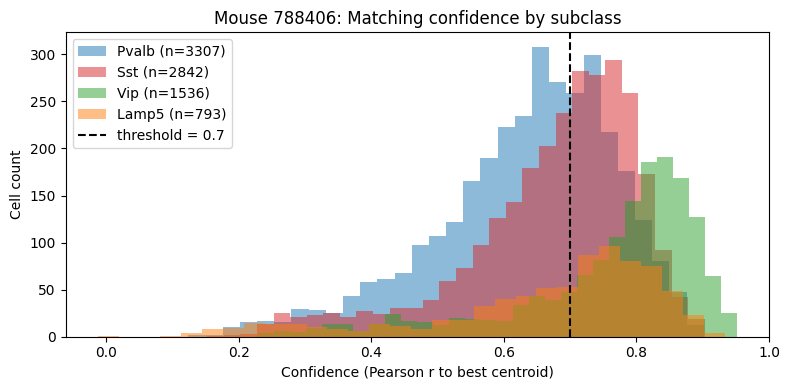

In [54]:
import matplotlib.pyplot as plt

# Confidence distribution per subclass (before filtering)
all_mouse = assignments[assignments["mouse_id"] == int(MOUSE_ID)].copy()
all_mouse["branch"] = all_mouse["assignment"].str.split("-").str[0]

branches = ["Pvalb", "Sst", "Vip", "Lamp5"]
fig, ax = plt.subplots(figsize=(8, 4))

for branch in branches:
    data = all_mouse.loc[all_mouse["branch"] == branch, "confidence"]
    if len(data) > 0:
        ax.hist(data, bins=30, alpha=0.5, label=f"{branch} (n={len(data)})",
                color=BRANCH_COLORS[branch])

ax.axvline(MIN_CONFIDENCE, color="k", linestyle="--", linewidth=1.5,
           label=f"threshold = {MIN_CONFIDENCE}")
ax.set_xlabel("Confidence (Pearson r to best centroid)")
ax.set_ylabel("Cell count")
ax.set_title(f"Mouse {MOUSE_ID}: Matching confidence by subclass")
ax.legend()
plt.tight_layout()

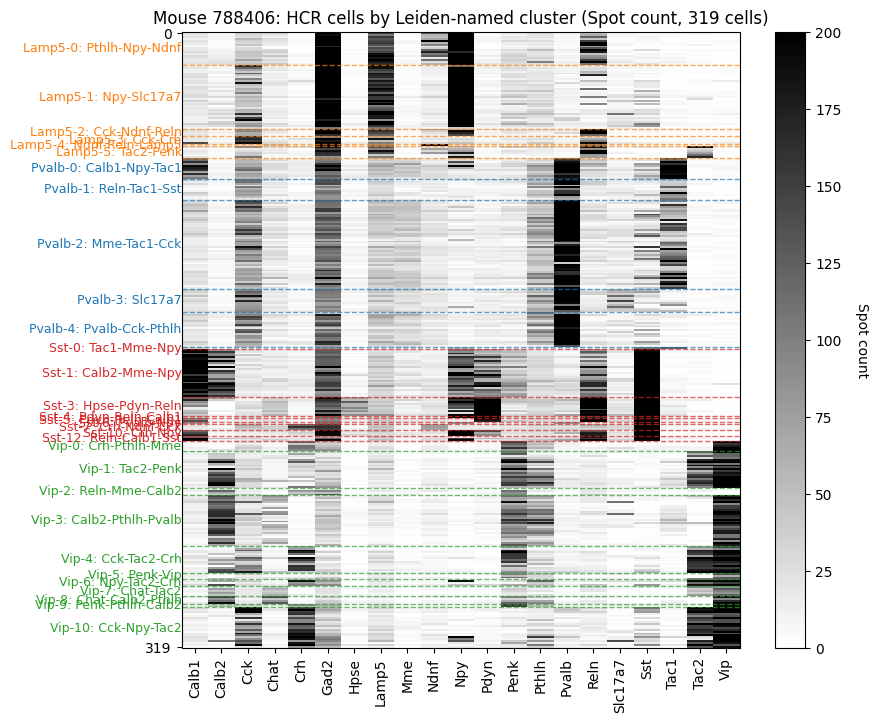

In [55]:
# Branch color palette — colors the cluster text labels by subclass
BRANCH_COLORS = {
    "Pvalb": "#1f77b4",  # blue
    "Sst": "#d62728",    # red
    "Vip": "#2ca02c",    # green
    "Lamp5": "#ff7f0e",  # orange
}

# Plot cell×gene heatmap with colored Leiden-named labels
fig_h = max(8, len(cxg_assigned) * 0.001)

fig, sorted_labels, sorted_cells = viz.plot_cell_x_gene_labeled(
    cxg_assigned,
    labels=labels_assigned,
    clip_range=CLIP_RANGE,
    fig_size=(9, fig_h),
    label_fontsize=9,
    cbar_label=scale_label,
    title=f"Mouse {MOUSE_ID}: HCR cells by Leiden-named cluster ({scale_label}, {len(cxg_assigned)} cells)",
    color_labels=BRANCH_COLORS,
)

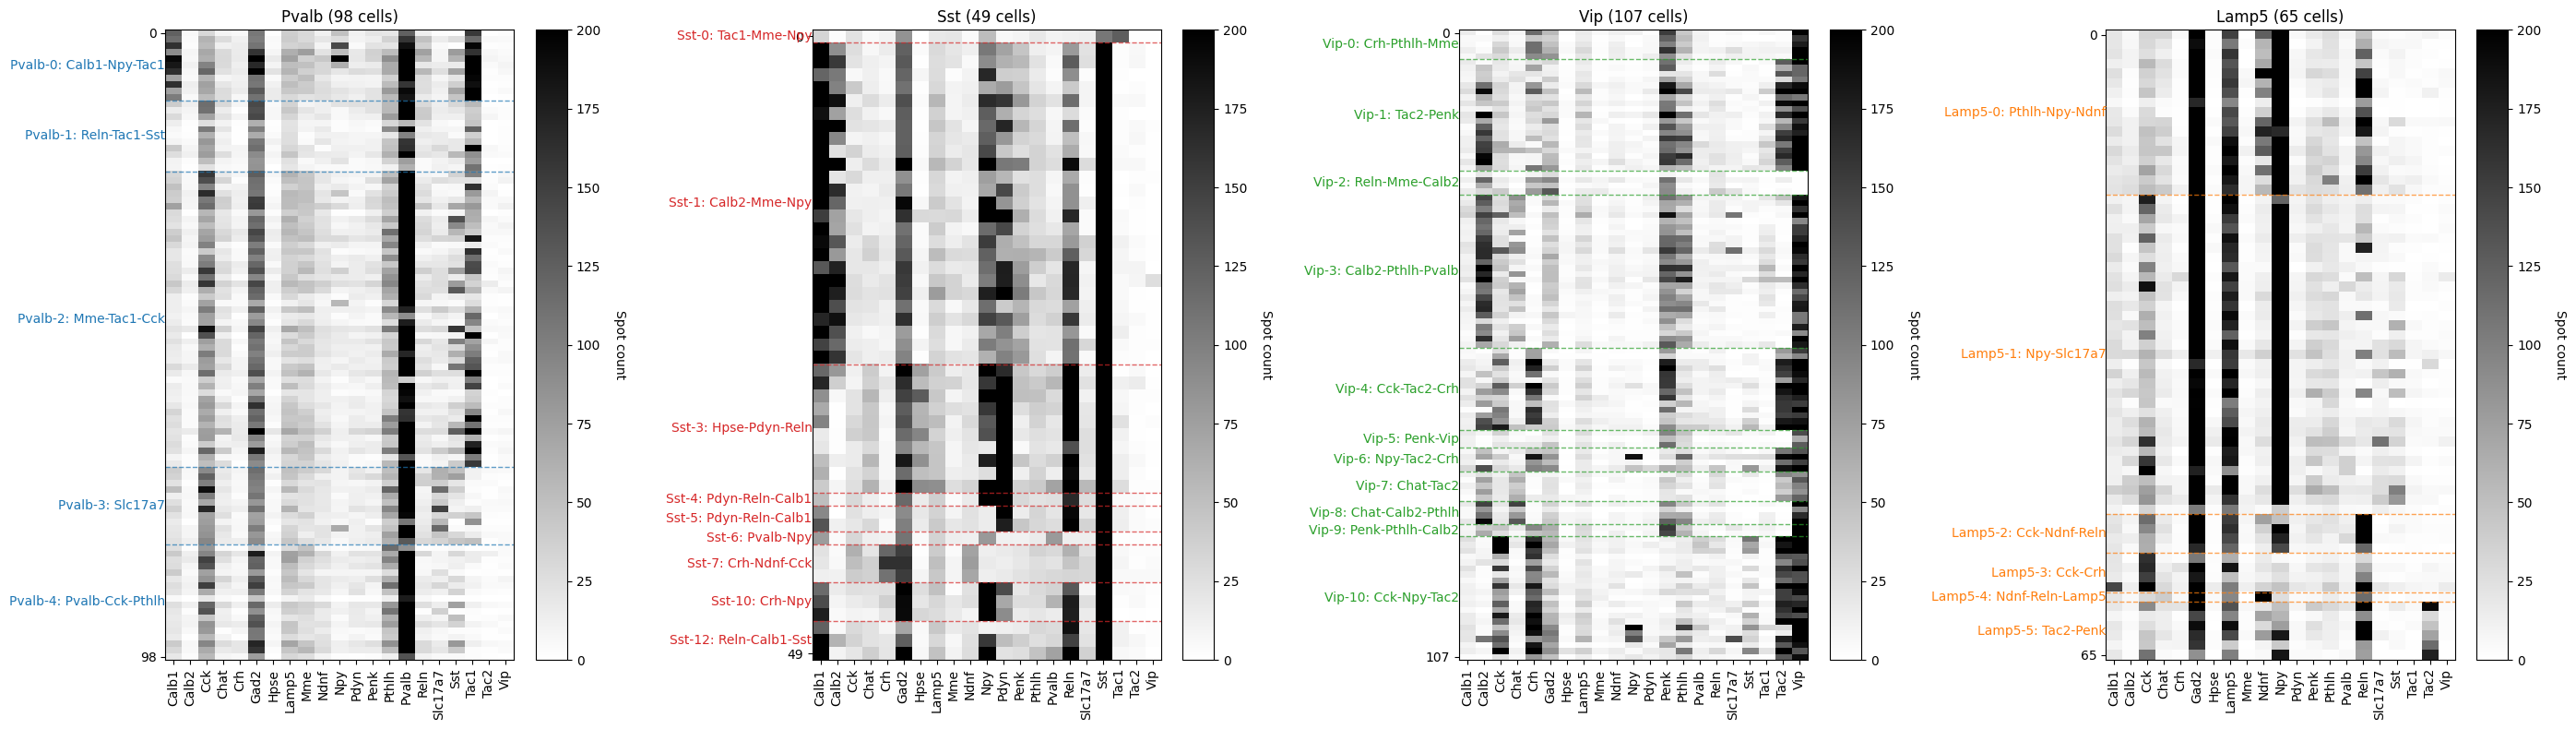

In [56]:
# Plot each subclass side by side
import matplotlib.pyplot as plt

branches = ["Pvalb", "Sst", "Vip", "Lamp5"]

# Split cells by branch
branch_data = {}
for branch in branches:
    mask = labels_assigned.str.startswith(branch + "-")
    if mask.any():
        branch_data[branch] = (cxg_assigned.loc[mask], labels_assigned.loc[mask])

n_branches = len(branch_data)
fig, axes = plt.subplots(1, n_branches, figsize=(7 * n_branches, 8))
if n_branches == 1:
    axes = [axes]

for ax, (branch, (branch_cxg, branch_labels)) in zip(axes, branch_data.items()):
    viz.plot_cell_x_gene_labeled(
        branch_cxg,
        labels=branch_labels,
        clip_range=CLIP_RANGE,
        fig_size=(5, 10),
        label_fontsize=10,
        cbar_label=scale_label,
        title=f"{branch} ({len(branch_cxg)} cells)",
        ax=ax,
        color_labels={branch: BRANCH_COLORS[branch]},
    )

plt.tight_layout()

In [23]:
import anndata as ad

# Load Tasic branch h5ad files saved by the pipeline (stage4)
STAGE4_DIR = Path("/root/capsule/results/hcr_tasic_matching/stage4")
canonical = ["Pvalb", "Sst", "Vip", "Lamp5"]

tasic_branch_data = {}
for branch in canonical:
    h5_path = STAGE4_DIR / branch.lower() / f"{branch}_branch_tasic.h5ad"
    names_path = STAGE4_DIR / branch.lower() / f"{branch}_cluster_names.csv"
    if not h5_path.exists():
        continue

    adata_br = ad.read_h5ad(h5_path)

    # Use log-normalized layer (not z-scored) for interpretable heatmap
    X_log = adata_br.layers["log_norm"] if "log_norm" in adata_br.layers else adata_br.X
    X_log = X_log if not hasattr(X_log, "toarray") else X_log.toarray()
    cxg_br = pd.DataFrame(X_log, columns=adata_br.var_names, index=adata_br.obs_names)

    # Load marker-derived cluster names
    names_df = pd.read_csv(names_path)
    name_map = dict(zip(names_df["branch_cluster"], names_df["marker_name"]))

    # Map branch_cluster → Leiden-named label (convert to str to avoid Categorical issues)
    branch_clusters = adata_br.obs["branch_cluster"].astype(str)
    labels_br = branch_clusters.map(name_map).fillna(branch_clusters)
    labels_br.name = "assignment"

    tasic_branch_data[branch] = (cxg_br, labels_br)
    print(f"{branch}: {len(cxg_br)} cells, {labels_br.nunique()} clusters")

print(f"\nLoaded Tasic Leiden clusters from stage4 output")

Pvalb: 1134 cells, 5 clusters
Sst: 1363 cells, 14 clusters
Vip: 1557 cells, 11 clusters
Lamp5: 1067 cells, 6 clusters

Loaded Tasic Leiden clusters from stage4 output


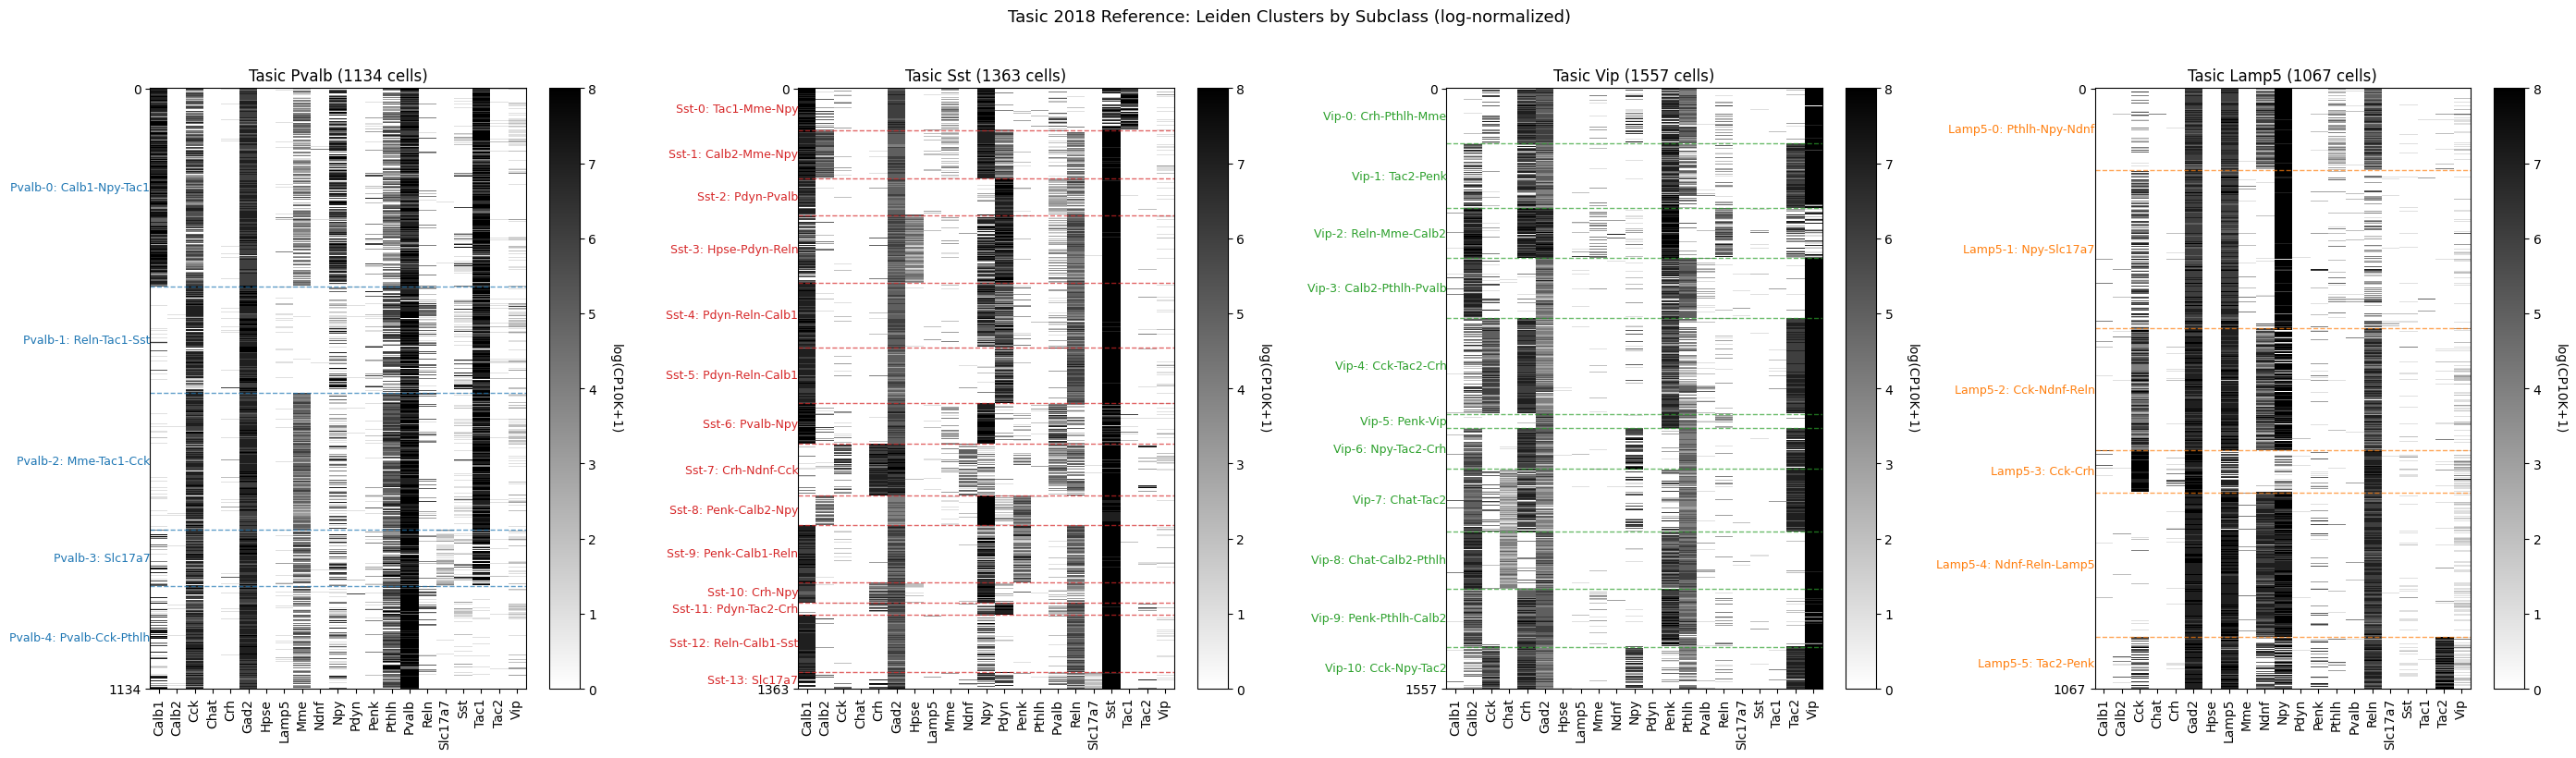

In [24]:
# Plot Tasic subclasses side by side with Leiden cluster labels (log-normalized)
TASIC_CLIP = (0, 8)  # log_cp10k scale

n_branches = len(tasic_branch_data)
fig, axes = plt.subplots(1, n_branches, figsize=(7 * n_branches, 8))
if n_branches == 1:
    axes = [axes]

for ax, (branch, (branch_cxg, branch_labels)) in zip(axes, tasic_branch_data.items()):
    viz.plot_cell_x_gene_labeled(
        branch_cxg,
        labels=branch_labels,
        clip_range=TASIC_CLIP,
        fig_size=(5, 10),
        label_fontsize=9,
        cbar_label="log(CP10K+1)",
        title=f"Tasic {branch} ({len(branch_cxg)} cells)",
        ax=ax,
        color_labels={branch: BRANCH_COLORS[branch]},
    )

plt.suptitle("Tasic 2018 Reference: Leiden Clusters by Subclass (log-normalized)", y=1.02, fontsize=13)
plt.tight_layout()

In [ ]:
# Save figure
out_path = RESULTS_DIR / f"cellxgene_raw_mouse_{MOUSE_ID}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")